Enter the following values to predict heart disease risk:


Enter value for age:  0
Enter value for sex:  0
Enter value for cp:  0
Enter value for trestbps:  0
Enter value for chol:  0
Enter value for fbs:  0
Enter value for restecg:  0
Enter value for thalach:  0
Enter value for exang:  0
Enter value for oldpeak:  0
Enter value for slope:  0
Enter value for ca:  0
Enter value for thal:  0


High risk of heart disease. Please consult a doctor.

Model Accuracy Evaluation:
Accuracy: 0.8360655737704918
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



C:\Users\prana.PRANAV\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


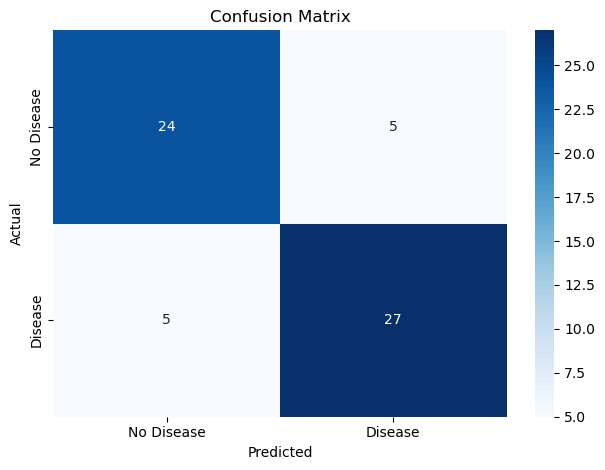

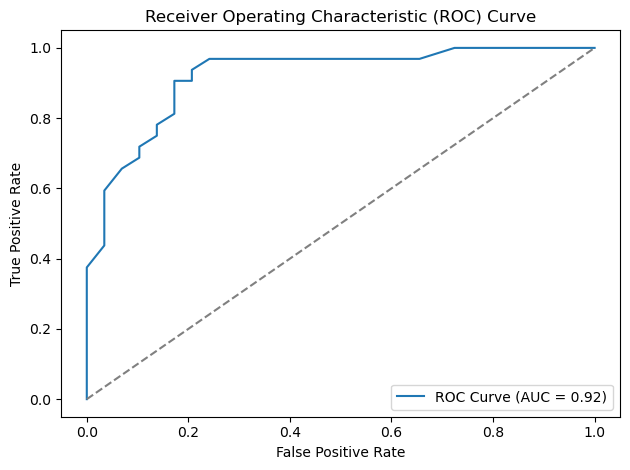

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
data = pd.read_csv('heart_disease_data.csv')
X = data.drop('target', axis=1)
y = data['target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Enter the following values to predict heart disease risk:")
user_input = []
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
            'exang', 'oldpeak', 'slope', 'ca', 'thal']
for feature in features:
    val = float(input(f"Enter value for {feature}: "))
    user_input.append(val)
user_input_scaled = scaler.transform([user_input])
prediction = model.predict(user_input_scaled)[0]
if prediction == 1:
    print("High risk of heart disease. Please consult a doctor.")
else:
    print("Low risk of heart disease. Keep maintaining a healthy lifestyle.")
print("\nModel Accuracy Evaluation:")
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.tight_layout()
plt.show()
